# Product Recommendation System from Retail Transactions

## Business problem

Retailers often miss opportunities to increase basket size by failing to
suggest relevant products at the right moment. Customers buying one item
frequently buy other related items as well, but without a systematic way
to detect these relationships, businesses rely on guesswork or generic
promotions rather than targeted recommendations.

This project aims to answer a practical question:

> **Given a product a customer is buying, what other products should be
> recommended to them?**

The resulting recommendations can support cross-selling strategies,
product placement, and personalized promotions.

## Objective

Build a product recommendation system based on market basket analysis,
identifying which products are frequently purchased together and using
those relationships to generate ranked recommendations for any given
product.

## Methodology

1. Data cleaning and transaction-level preparation
2. Exploratory analysis of basket size and product frequency
3. Market basket analysis using the Apriori algorithm
4. Association rule mining (support, confidence, lift)
5. Rule stability validation across multiple random samples
6. Recommendation function: given a product, return its top related items

In [1]:
import kagglehub
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from itertools import combinations
from collections import Counter
import seaborn as sns


In [2]:
# Download latest version
path = kagglehub.dataset_download("prasad22/retail-transactions-dataset")

## Dataset

The dataset contains retail transactions, including the list of products
purchased in each transaction, total cost, customer information, and
contextual details such as store type, city, and promotions.

In [3]:
csv_path = os.path.join(
    path,
    "Retail_Transactions_Dataset.csv"
)

df = pd.read_csv(csv_path)

df.head()

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,NaN
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,NaN
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items


In [4]:
import ast
# Convert string of lists into actual Python lists
df["Product"] = df["Product"].apply(ast.literal_eval)

In [5]:
df["basket_size"] = df["Product"].apply(len)
df["basket_size"].describe()

count    1000000.000000
mean           3.000343
std            1.413938
min            1.000000
25%            2.000000
50%            3.000000
75%            4.000000
max            5.000000
Name: basket_size, dtype: float64

**Note on data characteristics:** Product frequencies in this dataset are
nearly uniform (~36,000–37,000 occurrences each, with Toothpaste as a notable
outlier), unlike real-world retail data where a small number of products
typically dominate sales. This suggests limited natural co-purchase structure,
which is addressed directly in the findings below.

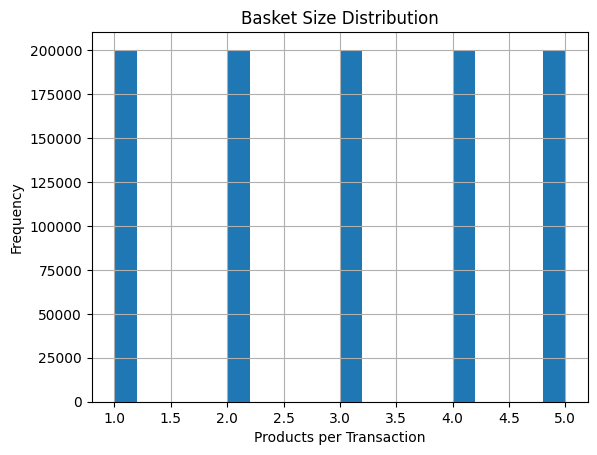

In [6]:
df["basket_size"].hist(bins=20)

plt.xlabel("Products per Transaction")
plt.ylabel("Frequency")
plt.title("Basket Size Distribution")

plt.show()

**Observation:** Basket sizes are nearly uniform, with counts close to
200,000 for each size from 1 to 5 items. This is the first sign that the
dataset may have limited natural variability in purchase behavior.

In [7]:
df['basket_size'].value_counts().reset_index()

,basket_size,count
0,3,200262
1,2,200151
2,5,200097
3,4,199760
4,1,199730


The catalog contains 81 unique products.

In [8]:
all_products = [
    product
    for basket in df["Product"]
    for product in basket
]
unique_products = len(set(all_products))

print(unique_products)

81


In [9]:
from collections import Counter

product_counts = Counter(all_products)

In [10]:
product_counts.most_common(80)

[('Toothpaste', 73324),
 ('Ice Cream', 37094),
 ('Soap', 37076),
 ('Jam', 36956),
 ('Orange', 36928),
 ('Soda', 36924),
 ('Deodorant', 36910),
 ('Cleaning Rags', 36870),
 ('Air Freshener', 36846),
 ('Peanut Butter', 36818),
 ('Banana', 36813),
 ('Baby Wipes', 36794),
 ('Cleaning Spray', 36774),
 ('Laundry Detergent', 36769),
 ('Yogurt', 36764),
 ('Plant Fertilizer', 36757),
 ('Ironing Board', 36755),
 ('Carrots', 36747),
 ('Mustard', 36746),
 ('Bath Towels', 36735),
 ('Beef', 36722),
 ('Chips', 36721),
 ('Honey', 36717),
 ('Shampoo', 36703),
 ('Milk', 36700),
 ('Insect Repellent', 36676),
 ('Extension Cords', 36669),
 ('Sponges', 36668),
 ('Tomatoes', 36667),
 ('Pasta', 36666),
 ('Coffee', 36664),
 ('Shaving Cream', 36661),
 ('Eggs', 36653),
 ('Trash Cans', 36647),
 ('Onions', 36645),
 ('Olive Oil', 36638),
 ('BBQ Sauce', 36626),
 ('Light Bulbs', 36624),
 ('Garden Hose', 36620),
 ('Rice', 36619),
 ('Potatoes', 36612),
 ('Cheese', 36605),
 ('Salmon', 36592),
 ('Feminine Hygiene Products

In [11]:
product_freq = pd.DataFrame(
    product_counts.items(),
    columns=["Product", "Count"]
)

product_freq = product_freq.sort_values(
    by="Count",
    ascending=False
)

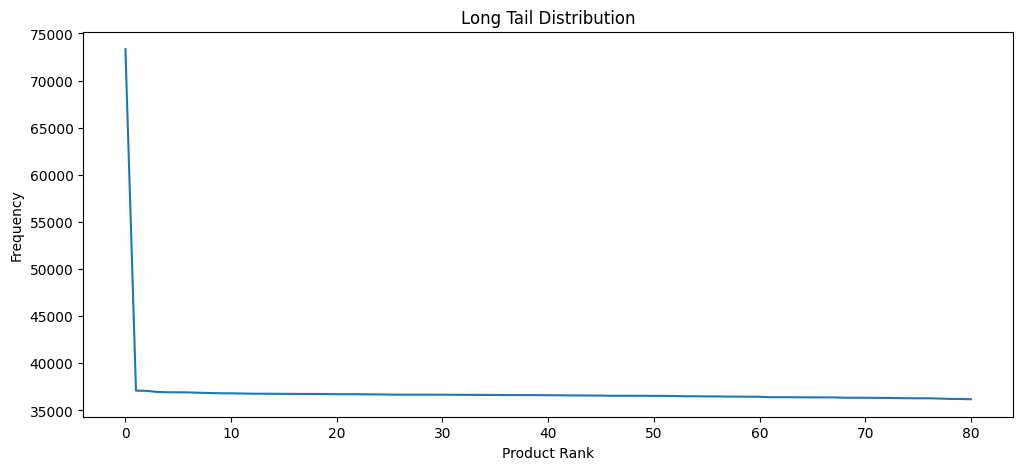

In [12]:
plt.figure(figsize=(12,5))

plt.plot(
    range(len(product_freq)),
    product_freq["Count"].values
)

plt.xlabel("Product Rank")
plt.ylabel("Frequency")
plt.title("Long Tail Distribution")

plt.show()

**Observation:** With the exception of Toothpaste, product frequencies are
nearly uniform across the catalog (~36,000–37,000 occurrences each). In
real-world retail data, a small number of products typically dominate sales
(e.g. milk, bread). This uniformity suggests the dataset may not capture
realistic purchasing patterns — a limitation that becomes important when
interpreting the association rules below.

In [13]:
pair_counts = Counter()
for basket in df["Product"]:
    
    unique_items = set(basket)
    
    for pair in combinations(unique_items, 2):
        
        pair = tuple(sorted(pair))
        
        pair_counts[pair] += 1

pair_counts.most_common(20)


[(('Tomatoes', 'Toothpaste'), 2412),
 (('Deodorant', 'Toothpaste'), 2405),
 (('Baby Wipes', 'Toothpaste'), 2396),
 (('Onions', 'Toothpaste'), 2388),
 (('Cheese', 'Toothpaste'), 2386),
 (('Toothbrush', 'Toothpaste'), 2377),
 (('Apple', 'Toothpaste'), 2368),
 (('Soap', 'Toothpaste'), 2367),
 (('Air Freshener', 'Toothpaste'), 2363),
 (('Olive Oil', 'Toothpaste'), 2358),
 (('Ironing Board', 'Toothpaste'), 2357),
 (('Ketchup', 'Toothpaste'), 2350),
 (('Shampoo', 'Toothpaste'), 2345),
 (('Peanut Butter', 'Toothpaste'), 2329),
 (('Plant Fertilizer', 'Toothpaste'), 2327),
 (('Extension Cords', 'Toothpaste'), 2325),
 (('Rice', 'Toothpaste'), 2325),
 (('Milk', 'Toothpaste'), 2325),
 (('Canned Soup', 'Toothpaste'), 2323),
 (('Toothpaste', 'Yogurt'), 2323)]

In [14]:
pairs_df = pd.DataFrame(
    pair_counts.items(),
    columns=["Pair", "Count"]
)
pairs_df[["Product_A", "Product_B"]] = pd.DataFrame(
    pairs_df["Pair"].tolist(),
    index=pairs_df.index
)
pairs_df = pairs_df.sort_values(
    by="Count",
    ascending=False
)


In [15]:
pairs_df.head(15)

,Pair,Count,Product_A,Product_B
1343,"(Tomatoes, Toothpaste)",2412,Tomatoes,Toothpaste
2230,"(Deodorant, Toothpaste)",2405,Deodorant,Toothpaste
537,"(Baby Wipes, Toothpaste)",2396,Baby Wipes,Toothpaste
2091,"(Onions, Toothpaste)",2388,Onions,Toothpaste
1998,"(Cheese, Toothpaste)",2386,Cheese,Toothpaste
802,"(Toothbrush, Toothpaste)",2377,Toothbrush,Toothpaste
2919,"(Apple, Toothpaste)",2368,Apple,Toothpaste
204,"(Soap, Toothpaste)",2367,Soap,Toothpaste
1050,"(Air Freshener, Toothpaste)",2363,Air Freshener,Toothpaste
203,"(Olive Oil, Toothpaste)",2358,Olive Oil,Toothpaste


In [16]:
#Exclude Toothpaste — its frequency is a clear outlier vs. the rest of the catalog, and including it would dominate the pair counts
pairs_df[(pairs_df.Product_B != "Toothpaste" )&( pairs_df.Product_A != "Toothpaste") ]

,Pair,Count,Product_A,Product_B
1782,"(Banana, Butter)",1295,Banana,Butter
1215,"(Deodorant, Feminine Hygiene Products)",1275,Deodorant,Feminine Hygiene Products
3199,"(BBQ Sauce, Yogurt)",1267,BBQ Sauce,Yogurt
1416,"(Chips, Peanut Butter)",1264,Chips,Peanut Butter
2632,"(Bath Towels, Orange)",1262,Bath Towels,Orange
...,...,...,...,...
2747,"(Extension Cords, Olive Oil)",1058,Extension Cords,Olive Oil
1488,"(Tuna, Water)",1048,Tuna,Water
817,"(Cereal Bars, Rice)",1043,Cereal Bars,Rice
2468,"(Canned Soup, Dish Soap)",1043,Canned Soup,Dish Soap


In [17]:
product_freq = Counter(all_products)
pairs_df["freq_A"] = pairs_df["Product_A"].map(product_freq)
pairs_df["freq_B"] = pairs_df["Product_B"].map(product_freq)
pairs_df["union"] = (
    pairs_df["freq_A"] +
    pairs_df["freq_B"] -
    pairs_df["Count"]
)
pairs_df["jaccard"] = (
    pairs_df["Count"] /
    pairs_df["union"]
)
pairs_df.sort_values(
    by="jaccard",
    ascending=False
).head(20)


,Pair,Count,Product_A,Product_B,freq_A,freq_B,union,jaccard
1343,"(Tomatoes, Toothpaste)",2412,Tomatoes,Toothpaste,36667,73324,107579,0.022421
2230,"(Deodorant, Toothpaste)",2405,Deodorant,Toothpaste,36910,73324,107829,0.022304
537,"(Baby Wipes, Toothpaste)",2396,Baby Wipes,Toothpaste,36794,73324,107722,0.022242
2091,"(Onions, Toothpaste)",2388,Onions,Toothpaste,36645,73324,107581,0.022197
1998,"(Cheese, Toothpaste)",2386,Cheese,Toothpaste,36605,73324,107543,0.022186
802,"(Toothbrush, Toothpaste)",2377,Toothbrush,Toothpaste,36501,73324,107448,0.022122
2919,"(Apple, Toothpaste)",2368,Apple,Toothpaste,36341,73324,107297,0.022070
1050,"(Air Freshener, Toothpaste)",2363,Air Freshener,Toothpaste,36846,73324,107807,0.021919
203,"(Olive Oil, Toothpaste)",2358,Olive Oil,Toothpaste,36638,73324,107604,0.021914
204,"(Soap, Toothpaste)",2367,Soap,Toothpaste,37076,73324,108033,0.021910


In [18]:
pairs_df.tail(5)

,Pair,Count,Product_A,Product_B,freq_A,freq_B,union,jaccard
2747,"(Extension Cords, Olive Oil)",1058,Extension Cords,Olive Oil,36669,36638,72249,0.014644
1488,"(Tuna, Water)",1048,Tuna,Water,36544,36217,71713,0.014614
817,"(Cereal Bars, Rice)",1043,Cereal Bars,Rice,36554,36619,72130,0.014460
2468,"(Canned Soup, Dish Soap)",1043,Canned Soup,Dish Soap,36213,36488,71658,0.014555
2743,"(Chicken, Toilet Paper)",1042,Chicken,Toilet Paper,36260,36290,71508,0.014572


Product pairs showed very little variability in both co-occurrence and
affinity, suggesting low structural differentiation between item
relationships in this dataset. Products tend to appear together in a
relatively uniform way, rather than forming strong, clearly distinguishable
associations. In real-world retail scenarios, stronger affinities would
typically emerge from consumption habits, product complementarity,
seasonality, and customer behavior patterns — none of which appear to be
meaningfully represented here.

## Market basket analysis

Using the Apriori algorithm, we identify combinations of products that
frequently appear together in the same transaction, then generate
association rules to quantify how strongly each pair is related.

In [19]:
# Convert transactions into one-hot encoded format required by Apriori
te = TransactionEncoder()

te_array = te.fit(df["Product"]).transform(df["Product"])

basket_df = pd.DataFrame(
    te_array,
    columns=te.columns_
)

In [20]:
basket_sample = basket_df.sample(
    100000,
    random_state=42
)
frequent_items = apriori(
    basket_sample,
    min_support=0.001,
    use_colnames=True,
    low_memory=True
)
rules = association_rules(
    frequent_items,
    metric="lift",
    min_threshold=1
)

In [21]:
rules.sort_values(
    by="lift",
    ascending=False
).head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
395,(Ironing Board),(Vacuum Cleaner),0.03575,0.03527,0.00147,0.041119,1.165832,1.0,0.000209,1.006100,0.147517,0.021136,0.006063,0.041399
394,(Vacuum Cleaner),(Ironing Board),0.03527,0.03575,0.00147,0.041678,1.165832,1.0,0.000209,1.006186,0.147444,0.021136,0.006148,0.041399
422,(Shower Gel),(Lawn Mower),0.03614,0.03528,0.00147,0.040675,1.152924,1.0,0.000195,1.005624,0.137613,0.021015,0.005592,0.041171
423,(Lawn Mower),(Shower Gel),0.03528,0.03614,0.00147,0.041667,1.152924,1.0,0.000195,1.005767,0.137491,0.021015,0.005734,0.041171
154,(Rice),(Cereal),0.03632,0.03616,0.00150,0.041300,1.142134,1.0,0.000187,1.005361,0.129136,0.021133,0.005332,0.041391
155,(Cereal),(Rice),0.03616,0.03632,0.00150,0.041482,1.142134,1.0,0.000187,1.005386,0.129115,0.021133,0.005357,0.041391
366,(Rice),(Ice Cream),0.03632,0.03596,0.00149,0.041024,1.140830,1.0,0.000184,1.005281,0.128097,0.021048,0.005253,0.041230
367,(Ice Cream),(Rice),0.03596,0.03632,0.00149,0.041435,1.140830,1.0,0.000184,1.005336,0.128049,0.021048,0.005308,0.041230
403,(Ketchup),(Pasta),0.03531,0.03631,0.00146,0.041348,1.138751,1.0,0.000178,1.005255,0.126305,0.020810,0.005228,0.040779
402,(Pasta),(Ketchup),0.03631,0.03531,0.00146,0.040209,1.138751,1.0,0.000178,1.005105,0.126436,0.020810,0.005079,0.040779


## Validating rule stability

A single run of Apriori could reflect random noise rather than a real
pattern. To check this, the analysis is repeated on 5 independent random
samples of the data, and only rules that consistently appear across samples
are considered reliable.

In [22]:
all_rules = []

for i in range(5):
    
    sample = basket_df.sample(
        100000,
        random_state=i
    )
    
    frequent_items = apriori(
        sample,
        min_support=0.001,
        use_colnames=True,
        low_memory=True
    )
    
    rules = association_rules(
        frequent_items,
        metric="lift",
        min_threshold=1
    )
    
    rules["sample"] = i
    
    all_rules.append(rules)

In [23]:
rules_df = pd.concat(
    all_rules,
    ignore_index=True
)
rules_df["antecedents"] = rules_df[
    "antecedents"
].apply(lambda x: ", ".join(list(x)))

rules_df["consequents"] = rules_df[
    "consequents"
].apply(lambda x: ", ".join(list(x)))
rules_df["rule"] = (
    rules_df["antecedents"]
    + " -> " +
    rules_df["consequents"]
)
rule_stability = (
    rules_df.groupby("rule")
    .size()
    .reset_index(name="times_appeared")
)

rule_stability.sort_values(
    by="times_appeared",
    ascending=False
).head(20)

,rule,times_appeared
2241,Water -> Deodorant,4
1442,Pasta -> Plant Fertilizer,4
1521,Plant Fertilizer -> Pasta,4
154,Bath Towels -> Diapers,4
1648,Salmon -> Chips,4
579,Diapers -> Bath Towels,4
576,Deodorant -> Water,4
1464,Peanut Butter -> Mayonnaise,4
1167,Mayonnaise -> Peanut Butter,4
458,Chips -> Salmon,4


**Conclusion on rule stability:** Association rules showed high consistency
across different random samples, indicating the patterns are stable rather
than noise. However, lift and confidence values remained low, suggesting
the relationships between products are weak. This reinforces the
hypothesis that the dataset behaves in a highly uniform, likely synthetic
way — limiting the strength of affinities typically seen in real-world
retail scenarios.

## Recommendation function

Given a product, this function returns its top related items ranked by
lift — the practical output of the market basket analysis above.

In [24]:
def recommend(product, rules_df, top_n=5):
    
    recommendations = (
        rules_df[
            rules_df["antecedents"]
            .str.contains(product)
        ]
        .sort_values(
            by="lift",
            ascending=False
        )
    )
    
    return recommendations[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(top_n)

**Example:** Recommendations generated for a customer purchasing Toothbrush.

In [25]:
recommend("Toothbrush", rules_df,10)

,antecedents,consequents,support,confidence,lift
388,Toothbrush,Hair Gel,0.00154,0.043295,1.203305
1880,Toothbrush,Broom,0.00141,0.039210,1.115512
1149,Toothbrush,Soda,0.00140,0.040369,1.110872
1648,Toothbrush,Onions,0.00145,0.040233,1.103788
2684,Toothbrush,Hair Gel,0.00141,0.038662,1.091220
2410,Toothbrush,Banana,0.00137,0.037565,1.066888
1126,Toothbrush,Shower Gel,0.00128,0.036909,1.058167
2758,Toothbrush,Lawn Mower,0.00136,0.037291,1.051930
2892,Toothbrush,Soap,0.00139,0.038114,1.049381
2326,Toothbrush,Yogurt,0.00136,0.037820,1.042730


Detalles de la columna:
| Columna    | Significado                        | Criterio|
| ---------- | ---------------------------------- | -|
| support    | frecuencia total de la combinación | |
| confidence | probabilidad condicional           | |
| lift       | fuerza REAL de la asociación       | *Si es mayor a 1 entonces es asociacion valida, entre mas cercana a 3 es mas fuerte|


In [26]:
affinity_matrix = basket_sample.astype(int).corr()
affinity_matrix.head()

,Air Freshener,Apple,BBQ Sauce,Baby Wipes,Banana,Bath Towels,Beef,Bread,Broom,Butter,...,Tomatoes,Toothbrush,Toothpaste,Trash Bags,Trash Cans,Tuna,Vacuum Cleaner,Vinegar,Water,Yogurt
Air Freshener,1.000000,-0.002492,-0.001589,-0.000647,0.000927,-0.005497,-0.001283,-0.000389,-0.007513,-0.005414,...,-0.002879,-0.002195,-0.005926,-0.003044,-0.003629,-0.004560,-0.003885,-0.005802,0.004029,-0.006322
Apple,-0.002492,1.000000,0.002983,-0.005273,-0.003074,-0.006715,-0.002183,-0.006136,-0.000122,-0.000880,...,-0.002915,-0.006517,-0.006234,-0.007711,-0.000511,-0.010837,-0.004241,-0.004138,-0.005176,-0.001513
BBQ Sauce,-0.001589,0.002983,1.000000,-0.005459,-0.004143,-0.000035,-0.004117,0.001927,-0.002643,-0.001689,...,-0.008267,-0.008687,0.000160,-0.006152,-0.007832,-0.004813,-0.005289,-0.004337,-0.002789,-0.000900
Baby Wipes,-0.000647,-0.005273,-0.005459,1.000000,-0.000360,0.000341,-0.002623,0.000603,0.000296,-0.003037,...,0.001834,-0.009238,-0.003088,-0.001790,-0.003234,-0.001853,-0.006131,-0.008315,0.002463,-0.009384
Banana,0.000927,-0.003074,-0.004143,-0.000360,1.000000,-0.002651,-0.009938,-0.001811,-0.002687,-0.002014,...,-0.008906,-0.003907,-0.007623,-0.006211,-0.006755,-0.003124,-0.006218,-0.004676,-0.005992,-0.007760


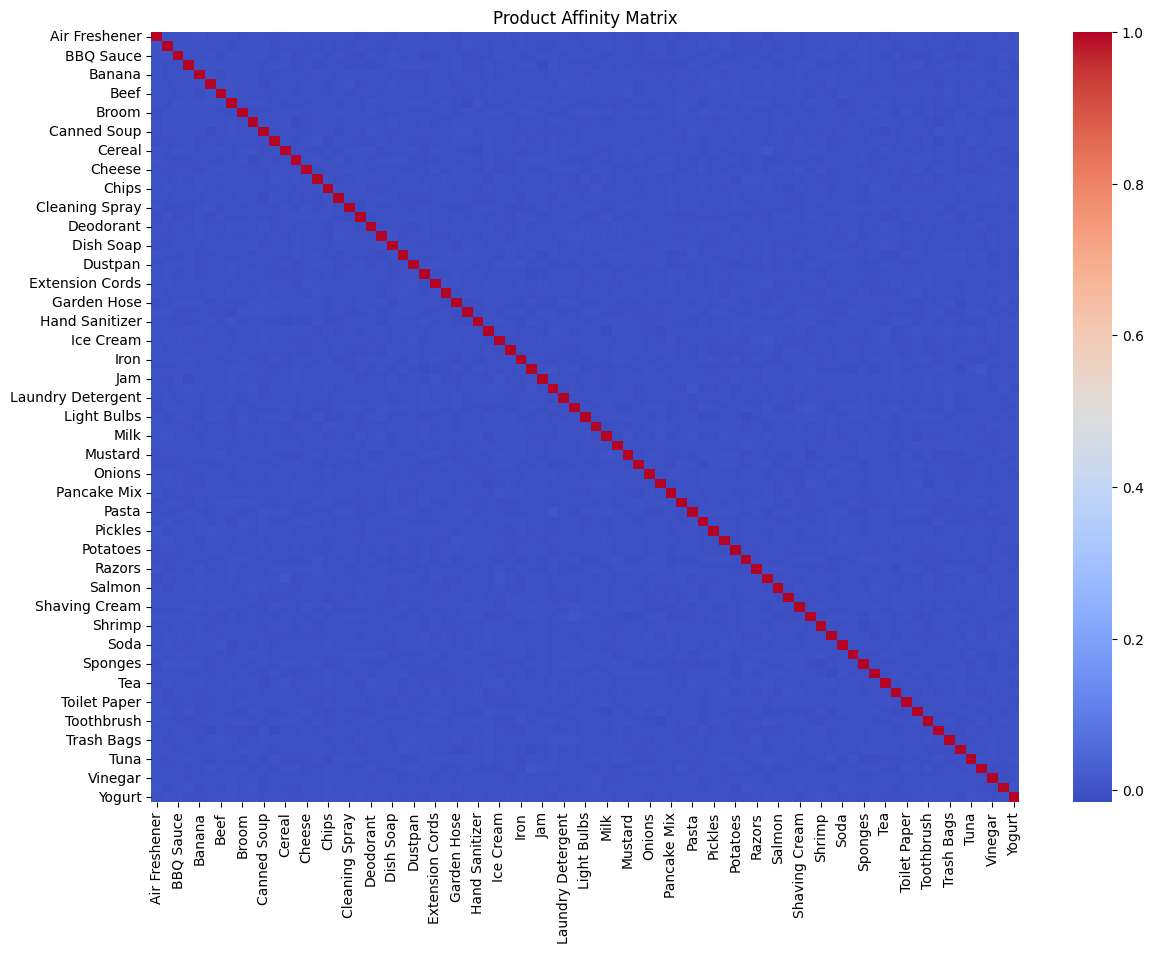

In [27]:
plt.figure(figsize=(14,10))

sns.heatmap(
    affinity_matrix,
    cmap="coolwarm"
)

plt.title("Product Affinity Matrix")
plt.show()

## Visualizing product affinity

To make the relationships easier to interpret, the affinity between the
15 most frequent products is visualized as a heatmap.

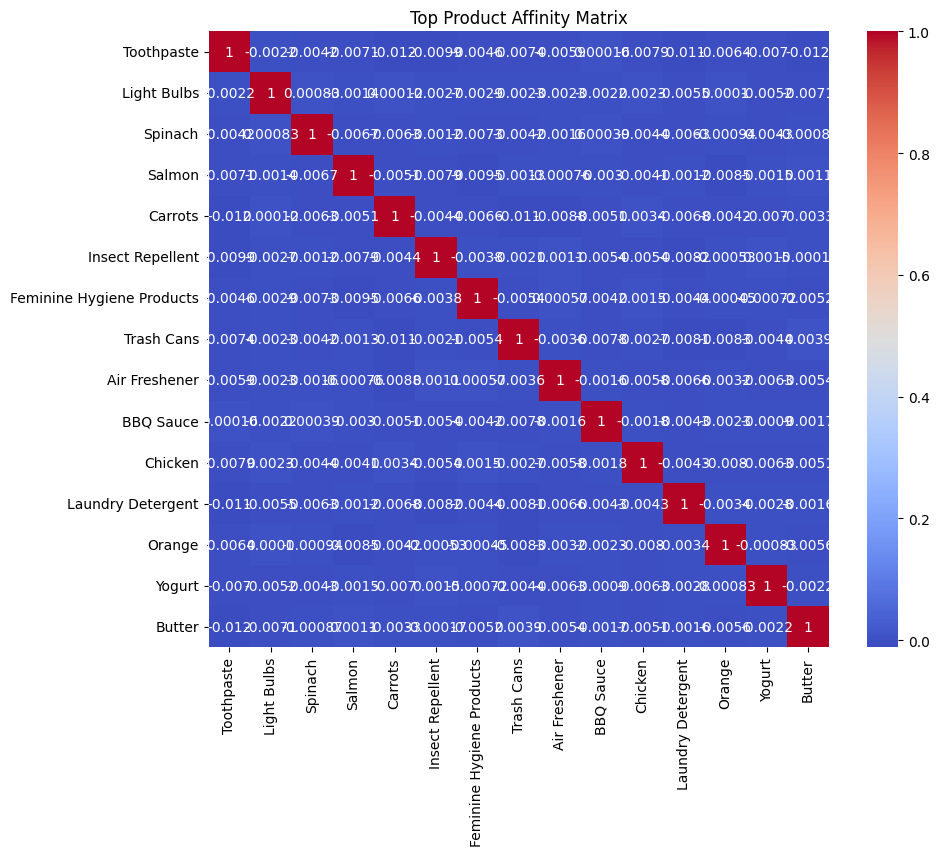

In [28]:
# Visualize co-purchase strength among the most frequent products only, since plotting all 81 products would be unreadable
top_products = (
    basket_sample.sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)
small_affinity = affinity_matrix.loc[
    top_products,
    top_products
]
plt.figure(figsize=(10,8))
sns.heatmap(
    small_affinity,
    annot=True,
    cmap="coolwarm"
)

plt.title("Top Product Affinity Matrix")
plt.show()

# Key Insights

## 1. The dataset shows limited natural co-purchase structure

Product frequencies are nearly uniform across the catalog (~36,000–37,000
occurrences each), and the strongest association rules found had a lift of
only ~1.16 — barely above the threshold of 1, which would indicate no
relationship at all. This suggests that, unlike real-world retail data,
this dataset does not capture strong natural buying patterns between
products.

## 2. The detected patterns are stable, even if weak

Re-running the analysis on 5 independent random samples produced largely
the same top rules each time, confirming that the (weak) relationships
found are consistent rather than random noise. This distinction matters:
a real recommendation system should be built on stable patterns, even when
those patterns are subtle.

## 3. The recommendation function works as designed, but is constrained by the data

The `recommend()` function correctly returns the top related items for any
given product, ranked by lift. However, given the weak associations in this
dataset, its recommendations would have limited practical impact in a real
business setting — the methodology is sound, but the input data limits the
strength of the output.

# Conclusion

This project demonstrates an end-to-end approach to building a product
recommendation system from retail transaction data, using market basket
analysis and association rule mining. The methodology — including frequency
analysis, rule mining, and stability validation across multiple samples —
is directly transferable to real-world retail data. In a business setting
with genuine co-purchase patterns, this same pipeline would be expected to
surface significantly stronger and more actionable recommendations.